In [1]:
#1 import libraries
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn

In [2]:
#2 import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [3]:
#3 connecting db
conn = sqlite3.connect('customer_churn.db')

sql_query = """
        select name 
        from sqlite_master
        where type = 'table';
"""
tables = pd.read_sql(sql_query,conn)

for table_name in tables['name']:
    df = pd.read_sql(f"select * from {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [4]:
#4 optional - About 3 tables
conn = sqlite3.connect('customer_churn.db')
for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    cols_query = f"PRAGMA table_info({table_name})";
    cols = pd.read_sql(cols_query, conn)
    print("Columns");
    print(cols['name'].tolist())

conn.close()


Table Name: db_customer
Columns
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [5]:
# DATA CLEANING
df_db_customer.head()
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,NaN,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,NaN,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,NaN,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,NaN,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,NaN,None


In [6]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [7]:
#import libraries
!pip install numpy
!pip install pandas
!pip install matplotlib.pyplot

ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)
ERROR: No matching distribution found for matplotlib.pyplot


In [8]:
#Things to do 
#1. Drop pincode & interest cols
#2. Rename name col
#3. Change datatype of dob
#4. standarsdize Gender col
#5. Fill missing values of country col

In [9]:
#1. Drop pincode & interest cols
df_db_customer.drop(columns = ['pincode', 'interests'], inplace = True)


In [10]:
df_db_customer

,customerid,name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [11]:
#2. Rename name col
df_db_customer.rename(columns = {'name' : 'Cust_name'}, inplace = True)

In [12]:
#3. Change datatype of dob
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   customerid  21 non-null     str  
 1   Cust_name   21 non-null     str  
 2   country     18 non-null     str  
 3   state       21 non-null     str  
 4   gender      21 non-null     str  
 5   dob         21 non-null     str  
dtypes: str(6)
memory usage: 1.1 KB


In [13]:
pd.to_datetime(df_db_customer['dob'])

0    1982-04-12
1    1995-11-23
2    1978-02-15
3    2001-08-30
4    1990-05-05
5    1988-12-10
6    1976-09-21
7    1999-03-14
8    1985-07-07
9    1993-10-29
10   1997-01-22
11   1981-06-18
12   2004-12-01
13   1992-04-25
14   1979-11-11
15   1986-02-28
16   1994-08-19
17   2000-09-02
18   1983-12-30
19   1991-05-14
20   1977-10-06
Name: dob, dtype: datetime64[us]

In [14]:
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [15]:
#4. standarsdize Gender col
df_db_customer['gender'].unique()

<StringArray>
['Male', 'Female', 'Women', 'Men']
Length: 4, dtype: str

In [16]:
df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'})

0       Male
1       Male
2     Female
3       Male
4     Female
5     Female
6     Female
7       Male
8     Female
9       Male
10      Male
11    Female
12    Female
13    Female
14      Male
15    Female
16    Female
17    Female
18      Male
19      Male
20    Female
Name: gender, dtype: str

In [17]:
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'})

In [18]:
#5. Fill missing values of country col
df_db_customer['country'].isna()

0     False
1     False
2     False
3     False
4     False
5      True
6     False
7     False
8      True
9     False
10    False
11    False
12     True
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
Name: country, dtype: bool

In [19]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,Cust_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [20]:
# country and state - unique value pair

# Creating state → country map from non-null rows
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

# Fill the missing country using State
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [21]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,Cust_name,country,state,gender,dob


In [22]:
#table1 cleaning is done

In [23]:
#table2 cleaning
df_db_subscription.head()
df_db_subscription.tail()
df_db_subscription.info()
#Everything looks clean just the all the date cols are in str datatype, so change it

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [24]:
#we can change 3 cols at a time
date_cols = ['subscription_start_date', 'renewal_date', 'cancellation_date']

df_db_subscription[date_cols].apply(pd.to_datetime)

,subscription_start_date,renewal_date,cancellation_date
0,2021-03-15,2025-03-15,NaT
1,2020-08-01,2024-08-01,2024-09-10
2,2022-11-20,2025-11-20,NaT
3,2019-05-10,2025-05-10,NaT
4,2023-01-05,2024-01-05,2024-02-28
5,2022-06-18,2025-06-18,NaT
6,2021-09-30,2024-09-30,2024-11-15
7,2020-02-14,2025-02-14,NaT
8,2023-07-22,2024-07-22,NaT
9,2022-04-03,2025-04-03,NaT


In [25]:
df_db_subscription[date_cols] = df_db_subscription[date_cols].apply(pd.to_datetime)

In [26]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [27]:
#Table3 cleaning
df_db_support.head()
df_db_support.tail()
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [28]:
#1. Drop col_1 as it is has no values i.e it is a garbage col & drop comment col as it is not so neccessary
#2. change datatype of complaint_date

In [29]:
#1. Drop col_1 as it is has no values i.e it is a garbage col & drop comment col as it is not so neccessary
df_db_support.drop(columns  = ['col_1', 'comment'], inplace = True)

In [30]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28 00:00:00,N,60
1,0003-MKNFE,2024-08-28 00:00:00,Y,10
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20
3,0013-MHZWF,2025-03-18 00:00:00,N,90
4,0013-SMEOE,2024-11-01 00:00:00,N,30
5,0017-IUDMW,2024-04-10 00:00:00,Y,25
6,0019-EFAEP,2024-09-27 00:00:00,Y,30
7,0022-TCJCI,2024-09-13 00:00:00,Y,10
8,0022-TCJCI,2024-09-14 00:00:00,N,90


In [31]:
#2. change datatype of complaint_date
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


In [32]:
# Feature Engineering and data analysis

In [35]:
print(tables)

              name
0      db_customer
1  db_subscription
2       db_support


In [36]:
df_db_subscription.head()
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [37]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


In [38]:
df_db_customer

,customerid,Cust_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,India,Delhi,Female,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,Nepal,Kathmandu,Female,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [39]:
df_db_subscription

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,22
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,5
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,34
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,NaN,6.99,335,41


In [40]:
# create a new col using existing col - churn flag

# Customer is churned if cancellation_date is not null
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)

In [41]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [44]:
#Merge 3 dfs into 1
(df_db_subscription
    .merge(df_db_customer, on = 'customerid', how = 'left')
    .merge(df_db_support, on = 'customerid', how = 'left'))

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,Cust_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN
5,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0
6,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,22,0,durga,India,Delhi,Female,1988-12-10,2025-03-18,N,90.0
7,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1,mina,India,Meghalaya,Female,1976-09-21,2024-11-01,N,30.0
8,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,5,0,madan,India,Rajasthan,Male,1999-03-14,NaT,NaN,NaN
9,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,34,0,maya,Nepal,Kathmandu,Female,1985-07-07,NaT,NaN,NaN


In [46]:
df_db_subscription.shape

(21, 12)

In [47]:
(df_db_subscription
    .merge(df_db_customer, on = 'customerid', how = 'left')
    .merge(df_db_support, on = 'customerid', how = 'left')).shape

(23, 20)

In [49]:
#if we see df_db_subscription has 21 rows and after merging we got 23 rows. It means we might have got dup in either of the 2 tables, lets check

df_db_customer.shape

(21, 6)

In [50]:
df_db_support.shape

(9, 4)

In [53]:
df_db_support['customerid'].nunique()

7

In [54]:
df_db_support['customerid'].size

9

In [55]:
#There you go we found 2 extra rows in the support table, Now lets check what are those
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [59]:
#Now we need to handle repeated values then merge
#We can see that if same cutomer has raised a complaint 2 times, 2 diff rows are created. Instead a separate col has to be there to maintain cutomer complaint count.
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [61]:
#Now we'll keep the latest complaint and remove the other
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep = 'last')
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
2,0013-EXCHZ,2024-01-20,Y,20,1
5,0017-IUDMW,2024-04-10,Y,25,1
1,0003-MKNFE,2024-08-28,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2
6,0019-EFAEP,2024-09-27,Y,30,1
4,0013-SMEOE,2024-11-01,N,30,1
3,0013-MHZWF,2025-03-18,N,90,1


In [62]:
df_db_support.shape

(7, 5)

In [67]:
#Cleaning is done, now merge
df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid', how = 'left')
    .merge(df_db_support, on = 'customerid', how = 'left'))

In [64]:
df

(21, 21)

In [ ]:
# DATA ANALYSIS

In [68]:
#Export the data into excel format so it is handy
df.to_csv('exported_churn_data.csv', index=False)

In [69]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'Cust_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [74]:
# 1. Churn Rate
churn_rate = df['churn_flag'].mean()*100
print("Churn Rate = ", round(churn_rate,2), "%")

Churn Rate =  28.57 %


In [77]:
# 2. Retenion Rate
retention_rate = 100 - churn_rate
print("Retention Rate = ", round(retention_rate,2), "%")

Retention Rate =  71.43 %


In [79]:
# 3. Churn by Plan type
church_by_plan = df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct')
print(church_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [81]:
# 4 a. Churn by state + sum(revenue) & count of users
church_by_state_Revloss_count = df.groupby('state').agg(
    churn_rate_pct=('churn_flag', lambda x: round(x.mean() * 100, 2)),
    total_revenue=('monthly_charges', 'sum'),
    user_count=('state', 'size')
).reset_index()

print(church_by_state_Revloss_count)

           state  churn_rate_pct  total_revenue  user_count
0          Delhi           25.00          52.96           4
1      Karnataka          100.00          20.98           2
2      Kathmandu            0.00          20.98           2
3    Maharashtra            0.00          50.97           3
4      Meghalaya           66.67          42.97           3
5       Nagaland            0.00          22.99           1
6      Rajasthan            0.00          36.98           2
7      Telangana           50.00          30.98           2
8  Uttar Pradesh            0.00         115.98           2


In [85]:
#4.b Churn by subscription type + sum(revenue) & count of users
churn_subscription_revLoss_count = df.groupby('plan_type').agg(
    churn_rate_perc = ('churn_flag', lambda x: round(x.mean() * 100, 2)),
    Sum_rev = ('monthly_charges','sum'),
    user_count = ('plan_type', 'size')
)
print(churn_subscription_revLoss_count)

           churn_rate_perc  Sum_rev  user_count
plan_type                                      
Basic                60.00    52.95           5
Premium              14.29   218.93           7
Standard             22.22   123.91           9


In [86]:
# 5. ARPU - Avg Revenue per user
arpu = df['monthly_charges'].mean()
print('ARPU = ', round(arpu,2))

ARPU =  18.85


In [98]:
# homework - calculate customer age
age = (today - df['dob']).dt.days // 365
age

0     44
1     30
2     48
3     25
4     36
5     37
6     49
7     27
8     41
9     32
10    29
11    45
12    21
13    34
14    46
15    40
16    32
17    26
18    42
19    35
20    48
Name: dob, dtype: int64

In [99]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'Cust_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [165]:
# 6. Avg Customer Tenure
# count of days users has used our service : cancellation date else current date
today = pd.Timestamp.today()
today

df['tenure'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days
)

In [103]:
avg_tenure = df['tenure'].mean()
print("Avg Tenure : ", round(avg_tenure, 0))

Avg Tenure :  1530.0


In [107]:
# 7. Revenue at risk - revenue lost from churned users
rev_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("Revenue loss(Rs K)", rev_at_risk)

Revenue loss(Rs K) 73.94


In [108]:
# 8. Esclation Rate
df['escalations'].unique()

<StringArray>
[nan, 'Y', 'N']
Length: 3, dtype: str

In [112]:
escalation_rate = (df['escalations']=='Y').mean()*100
print("Escalation rate", round(escalation_rate, 2))

Escalation rate 19.05


In [114]:
# 9. Avg Complaint Per User
avg_comps_per_user = df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg Compliants Per User = ", round(avg_comps_per_user, 2))

Avg Compliants Per User =  0.43


In [140]:
# 10. Correlation Esclation vs Churn
df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0)
df[['escalations', 'churn_flag']].dropna()
#Correlation = corr_df['escalations'].corr(corr_df['churn_flag'])
#print("Correlation between escalation vs churn is =", round(Correlation, 2))
df['churn_flag']

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
Name: escalations, dtype: int64

In [139]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,Cust_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,1997.0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,0,10.0,2.0,1501.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1382.0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,mohan,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2672.0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,mira,India,Delhi,Female,1990-05-05,2024-01-20,0,20.0,1.0,419.0


In [141]:
df['escalations'].value_counts()

escalations
0    21
Name: count, dtype: int64

In [145]:
df = pd.read_csv('exported_churn_data.csv')

In [146]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,Cust_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,15-03-2021,Refferal,15-03-2025,Standard,Annual,NaN,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,12-04-1982,NaN,NaN,NaN,NaN
1,0003-MKNFE,01-08-2020,Paid,01-08-2024,Premium,Annual,10-09-2024,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,23-11-1995,28-08-2024,Y,10.0,2.0
2,0004-TLHLJ,20-11-2022,Organic,20-11-2025,Basic,Monthly,NaN,NaN,6.99,210,...,0,lalita,India,Delhi,Female,15-02-1978,NaN,NaN,NaN,NaN
3,0011-IGKFF,10-05-2019,Paid,10-05-2025,Premium,Annual,NaN,NaN,22.99,1725,...,0,mohan,India,Nagaland,Male,30-08-2001,NaN,NaN,NaN,NaN
4,0013-EXCHZ,05-01-2023,Refferal,05-01-2024,Standard,Monthly,28-02-2024,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,05-05-1990,20-01-2024,Y,20.0,1.0


In [150]:
df[['escalations', 'churn_flag']].dropna()

,escalations,churn_flag
1,Y,1
4,Y,1
5,N,0
6,N,1
11,Y,1
13,Y,1
18,N,1


In [158]:
df['escalations'] = df['escalations'].map({'Y': 1, 'N': 0})  # keeps NaN as NaN
corr_df = df[['escalations', 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(corr_df['churn_flag'])  # both from corr_df
print("Correlation between escalation vs churn is = ", round(correlation,2))

Correlation between escalation vs churn is =  nan


In [159]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'Cust_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'churn_risk'],
      dtype='str')

In [156]:
# 11. Create a column using existing col - Churn risk
conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] > 70)
]

choices = ['low', 'medium', 'high']
df['churn_risk'] = np.select(conditions, choices, default = 'unknow')

In [157]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,Cust_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,15-03-2025,Standard,Annual,NaN,NaN,13.99,627,...,keshav,India,Maharashtra,Male,12-04-1982,NaN,NaN,NaN,NaN,low
1,0003-MKNFE,2020-08-01,Paid,01-08-2024,Premium,Annual,10-09-2024,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,23-11-1995,28-08-2024,1.0,10.0,2.0,high
2,0004-TLHLJ,2022-11-20,Organic,20-11-2025,Basic,Monthly,NaN,NaN,6.99,210,...,lalita,India,Delhi,Female,15-02-1978,NaN,NaN,NaN,NaN,low
3,0011-IGKFF,2019-05-10,Paid,10-05-2025,Premium,Annual,NaN,NaN,22.99,1725,...,mohan,India,Nagaland,Male,30-08-2001,NaN,NaN,NaN,NaN,low
4,0013-EXCHZ,2023-01-05,Refferal,05-01-2024,Standard,Monthly,28-02-2024,Too expensive,13.99,195,...,mira,India,Delhi,Female,05-05-1990,20-01-2024,1.0,20.0,1.0,high


In [163]:
df['subscription_start_date'] = pd.to_datetime(df['subscription_start_date'], dayfirst=True)
df['cancellation_date'] = pd.to_datetime(df['cancellation_date'], dayfirst=True)

In [166]:
#Visualizing using matplotlib
df.shape

(21, 23)

In [169]:
# best practice to create a copy then work on it
df_visual = df.copy()
df_visual.shape
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'Cust_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'churn_risk', 'tenure'],
      dtype='str')

In [171]:
# 4.1 Monthly Churn Trend (Time Series KPI)
df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

In [172]:
df_visual.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,churn_risk,tenure,cancellation_month
0,0002-ORFBO,2021-03-15,Refferal,15-03-2025,Standard,Annual,NaT,NaN,13.99,627,...,Maharashtra,Male,12-04-1982,NaN,NaN,NaN,NaN,low,1997.0,NaT
1,0003-MKNFE,2020-08-01,Paid,01-08-2024,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Karnataka,Male,23-11-1995,28-08-2024,NaN,10.0,2.0,high,1501.0,2024-09
2,0004-TLHLJ,2022-11-20,Organic,20-11-2025,Basic,Monthly,NaT,NaN,6.99,210,...,Delhi,Female,15-02-1978,NaN,NaN,NaN,NaN,low,1382.0,NaT
3,0011-IGKFF,2019-05-10,Paid,10-05-2025,Premium,Annual,NaT,NaN,22.99,1725,...,Nagaland,Male,30-08-2001,NaN,NaN,NaN,NaN,low,2672.0,NaT
4,0013-EXCHZ,2023-01-05,Refferal,05-01-2024,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,Delhi,Female,05-05-1990,20-01-2024,NaN,20.0,1.0,high,419.0,2024-02


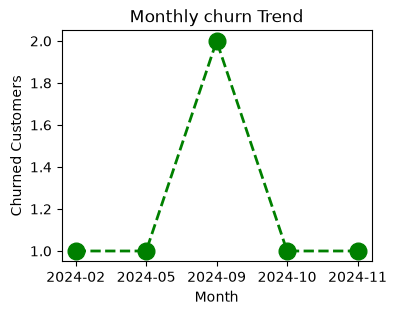

In [181]:
churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()
plt.figure(figsize = (4,3))
plt.plot(churn_trend.index.astype('str'), churn_trend.values, color='green', marker='o', linestyle='dashed',  linewidth=2, markersize=12)
plt.title('Monthly churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

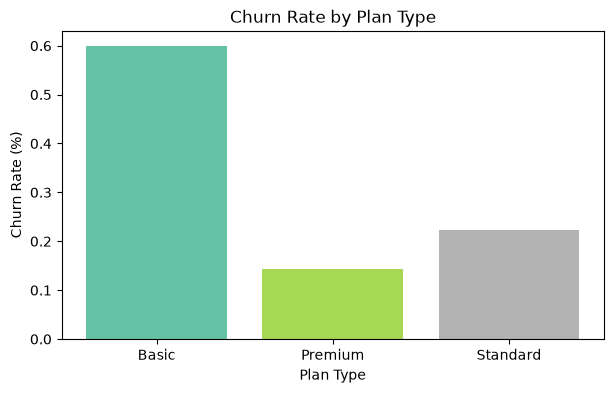

In [190]:
# 4.2 Churn Rate by Plan type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()
plt.figure(figsize=(7,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))
plt.title('Churn Rate by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate (%)')
plt.show()

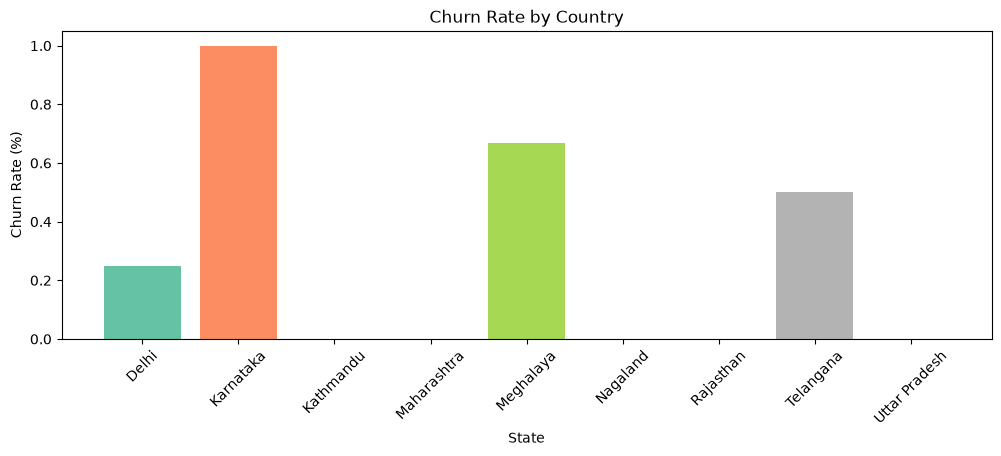

In [191]:
# 4.3 Churn by States
churn_plan = df_visual.groupby('state')['churn_flag'].mean()

# colors = ['yellow', 'purple', 'blue']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(12,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)

plt.title('Churn Rate by Country')
plt.xlabel('State')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.show()

In [193]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'Cust_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'churn_risk', 'tenure', 'cancellation_month'],
      dtype='str')

In [203]:
#VISUALIZATION USING SEABORN
# Heatmap (Correlation Matrix)
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score' , 'churn_flag', 'churn_risk', 'escalations']]
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,NaN
1,Premium,Annual,91,1,high,NaN
2,Basic,Monthly,34,0,low,NaN
3,Premium,Annual,8,0,low,NaN
4,Standard,Monthly,88,1,high,NaN


In [204]:
# incorrect method of encoding - as numbers are not assigned based on priority
categorial_cols = ['plan_type', 'contract_type', 'churn_risk']
for col in categorial_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

<Axes: >

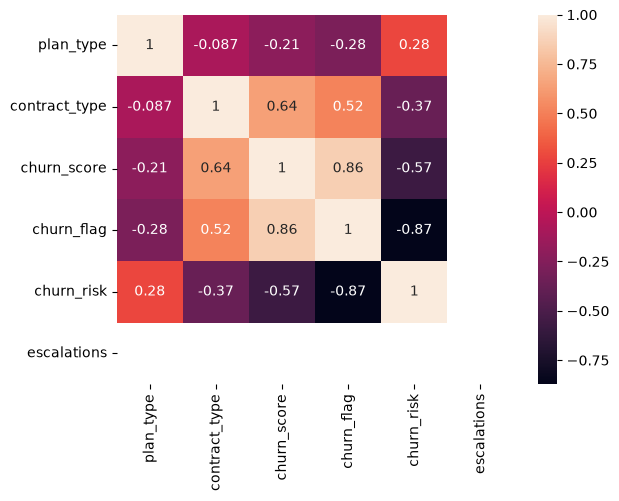

In [205]:

sns.heatmap(df_encoded.corr(), annot=True)

In [206]:
df_visual['plan_type'].unique()
df_visual['contract_type'].unique()
df_visual['churn_risk'].unique()

<StringArray>
['Standard', 'Premium', 'Basic']
Length: 3, dtype: str

In [210]:
#correct method of encoding - based on priority
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

order_mappings = {
    'plan_type' : ['Basic', 'Standard', 'Premium'],
    'contract_type' : ['Monthly', 'Annual'],
    'churn_risk': ['low', 'med', 'high']
    }

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

C:\Users\BRIGHTY\AppData\Local\Temp\ipykernel_25196\923030175.py:11: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes


In [208]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,NaN
1,Premium,Annual,91,1,high,NaN
2,Basic,Monthly,34,0,low,NaN
3,Premium,Annual,8,0,low,NaN
4,Standard,Monthly,88,1,high,NaN


In [211]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,NaN
1,2,1,91,1,2,NaN
2,0,0,34,0,0,NaN
3,2,1,8,0,0,NaN
4,1,0,88,1,2,NaN


<Axes: >

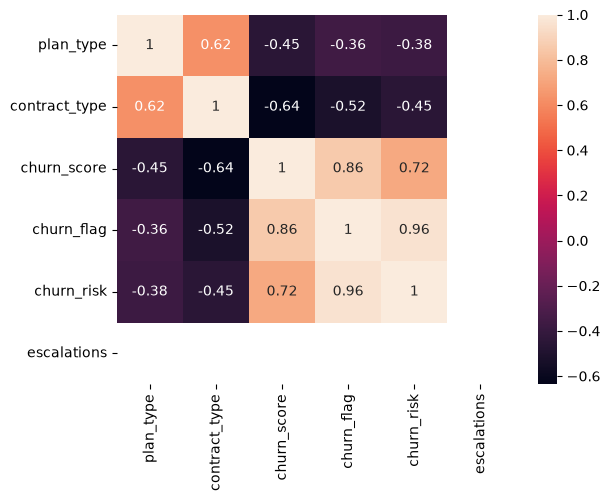

In [212]:
#Vorrect Heatmap (correlation matrix)
sns.heatmap(df_encoded.corr(), annot=True)

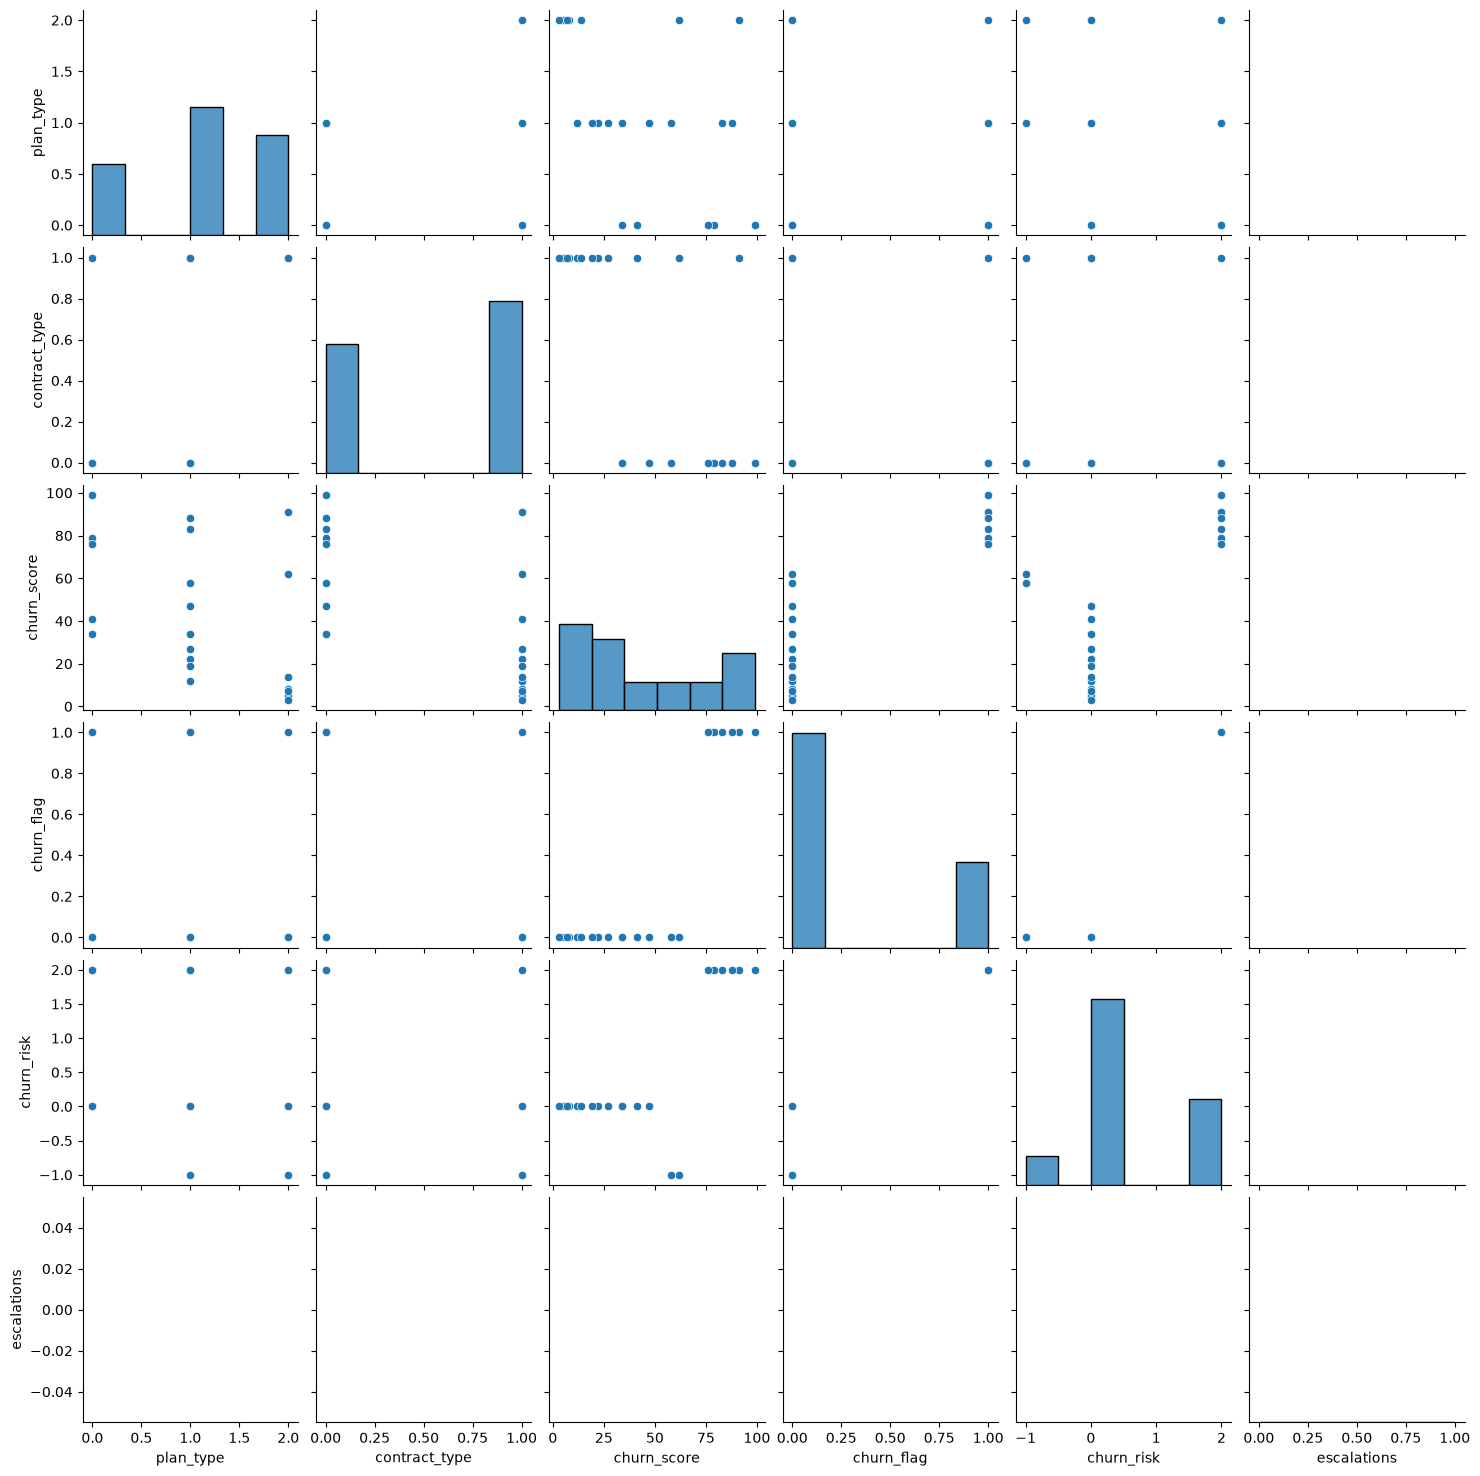

In [213]:
# pairplot - Plot pairwise relationships in a dataset
sns.pairplot(df_encoded)

In [217]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'Cust_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'churn_risk', 'tenure', 'cancellation_month'],
      dtype='str')

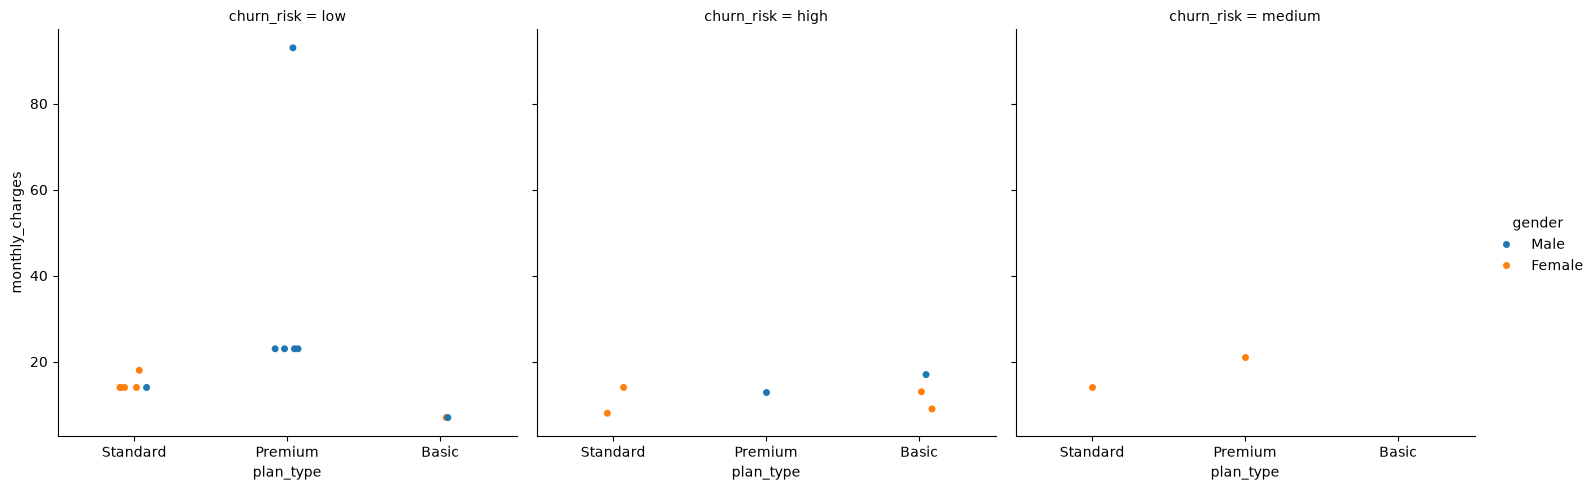

In [216]:
sns.catplot(
    data = df_visual,
    x = 'plan_type',
    y = 'monthly_charges',
    hue = 'gender',
    col = 'churn_risk'
)

In [218]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'Cust_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'churn_risk', 'tenure', 'cancellation_month'],
      dtype='str')

In [221]:
#PIVOT TABLE
#Basic pivot table
pd.pivot_table(
    df_visual,
    index = 'plan_type',
    values = 'churn_flag',
    aggfunc = 'mean'
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [222]:
#Complicated pivot table
pd.pivot_table(
    df_visual,
    index = 'plan_type',
    values = ['customerid', 'monthly_charges', 'churn_flag'],
    aggfunc = {
        'customerid' : 'nunique', 
        'monthly_charges' : 'sum', 
        'churn_flag' : 'mean'
    }
).reset_index()

,plan_type,churn_flag,customerid,monthly_charges
0,Basic,0.600000,5,52.95
1,Premium,0.142857,7,218.93
2,Standard,0.222222,9,123.91


In [223]:
# create db in sql

In [226]:
conn = sqlite3.connect('test_database.sqlite')

In [230]:
conn.execute(" create table users (first_name TEXT, country TEXT, budget INTEGER)")


OperationalError: table users already exists

In [232]:
print("Cretaed Table successfully!")

Cretaed Table successfully!


In [231]:
conn.commit()

In [234]:
# insert data
cursor = conn.cursor()

In [235]:
cursor.execute(
    """
    INSERT INTO users VALUES
            ('Madhav', 'India', 5000),
            ('Rishabh', 'Germany', 2500),
            ('Vishakha', 'India', 3500)
    """
)

In [236]:
conn.commit()

print("Data Inserted successfully!")

Data Inserted successfully!


In [237]:
# check inserted data in table

conn = sqlite3.connect('test_database.sqlite')

In [240]:
query = "select * from users"
df_result = pd.read_sql(query, conn)
df_result

,first_name,country,budget
0,Madhav,India,5000
1,Rishabh,Germany,2500
2,Vishakha,India,3500


In [241]:
# aggregation
query = """
        SELECT country, SUM(budget) as total_budget
        FROM users
        GROUP BY country
"""
df_agg = pd.read_sql(query, conn)
df_agg

,country,total_budget
0,Germany,2500
1,India,8500


In [242]:
conn.close()